<a href="https://colab.research.google.com/github/springboardmentor468a/Projects/blob/ImageSegmentation-AryaaAgarwal/week5_FinalTrainedMode.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install torch torchvision albumentations pycocotools -q

import os
import time
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision
import torchvision.models.segmentation as models
import albumentations as A
from albumentations.pytorch import ToTensorV2
from torchvision.datasets import CocoDetection
from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt
from google.colab import drive

In [2]:
# Mount Google Drive
drive.mount('/content/drive')

# Paths
train_root = "/content/drive/MyDrive/VisionExtraction/val2017"
train_ann  = "/content/drive/MyDrive/VisionExtraction/annotations/instances_val2017.json"

val_root   = train_root
val_ann    = train_ann

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Mounted at /content/drive
Using device: cuda


In [3]:
class CocoSegmentation(torch.utils.data.Dataset):
    def __init__(self, root, annFile, transforms=None):
        self.dataset = CocoDetection(root, annFile)
        self.transforms = transforms

    def __getitem__(self, idx):
        img, target = self.dataset[idx]
        img = np.array(img)

        # Binary mask: object vs background
        mask = np.zeros((img.shape[0], img.shape[1]), dtype=np.uint8)
        for obj in target:
            rle = self.dataset.coco.annToMask(obj)
            mask = np.maximum(mask, rle)

        mask = mask.astype(np.float32)

        if self.transforms:
            augmented = self.transforms(image=img, mask=mask)
            img, mask = augmented["image"], augmented["mask"]

        return img, mask.long()

    def __len__(self):
        return len(self.dataset)

In [4]:
train_transform = A.Compose([
    A.Resize(256, 256),
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(p=0.2),
    A.Normalize(mean=(0.485, 0.456, 0.406),
                std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])

val_transform = A.Compose([
    A.Resize(256, 256),
    A.Normalize(mean=(0.485, 0.456, 0.406),
                std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])

In [5]:
train_dataset = CocoSegmentation(train_root, train_ann, transforms=train_transform)
val_dataset   = CocoSegmentation(val_root, val_ann, transforms=val_transform)

train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True,
                          num_workers=4, pin_memory=True)
val_loader   = DataLoader(val_dataset, batch_size=4, shuffle=False,
                          num_workers=4, pin_memory=True)

print("Train images:", len(train_dataset))
print("Val images:", len(val_dataset))

loading annotations into memory...
Done (t=2.32s)
creating index...
index created!
loading annotations into memory...
Done (t=1.49s)
creating index...
index created!
Train images: 5000
Val images: 5000


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


In [6]:
model = models.deeplabv3_resnet50(pretrained=True)
model.classifier[4] = nn.Conv2d(256, 2, kernel_size=1)  # 2 classes
model = model.to(device)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=DeepLabV3_ResNet50_Weights.COCO_WITH_VOC_LABELS_V1`. You can also use `weights=DeepLabV3_ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/deeplabv3_resnet50_coco-cd0a2569.pth" to /root/.cache/torch/hub/checkpoints/deeplabv3_resnet50_coco-cd0a2569.pth


100%|██████████| 161M/161M [00:02<00:00, 77.7MB/s]


In [7]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)
scaler = torch.cuda.amp.GradScaler()  # Mixed precision

def dice_coefficient(pred, target, smooth=1e-6):
    pred = torch.argmax(pred, dim=1)
    intersection = (pred * target).sum()
    return (2. * intersection + smooth) / (pred.sum() + target.sum() + smooth)

/tmp/ipython-input-2714926423.py:3: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()  # Mixed precision


In [9]:
num_epochs = 30
best_val_dice = 0.0
save_path = "/content/drive/MyDrive/VisionExtraction/Projects/best_model.pth"
os.makedirs(os.path.dirname(save_path), exist_ok=True)

for epoch in range(num_epochs):
    start_time = time.time()
    model.train()
    train_loss, train_dice = 0, 0

    print(f"\nEpoch {epoch+1}/{num_epochs}")

    # -------------------------------
    # Training
    # -------------------------------
    for images, masks in tqdm(train_loader, desc="Training", unit="batch", ncols=100):
        images, masks = images.to(device), masks.to(device)
        optimizer.zero_grad()

        with torch.cuda.amp.autocast():
            outputs = model(images)['out']
            loss = criterion(outputs, masks)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        train_loss += loss.item()
        train_dice += dice_coefficient(outputs, masks).item()

    # -------------------------------
    # Validation
    # -------------------------------
    model.eval()
    val_loss, val_dice = 0, 0
    with torch.no_grad():
        for images, masks in tqdm(val_loader, desc="Validation", unit="batch", ncols=100):
            images, masks = images.to(device), masks.to(device)
            outputs = model(images)['out']
            loss = criterion(outputs, masks)

            val_loss += loss.item()
            val_dice += dice_coefficient(outputs, masks).item()

    epoch_time = time.time() - start_time
    print(f"Epoch {epoch+1} completed in {epoch_time:.2f}s")
    print(f"Train Loss: {train_loss/len(train_loader):.4f}, Train Dice: {train_dice/len(train_loader):.4f} | "
          f"Val Loss: {val_loss/len(val_loader):.4f}, Val Dice: {val_dice/len(val_loader):.4f}")

    # Save best model
    if val_dice/len(val_loader) > best_val_dice:
        best_val_dice = val_dice/len(val_loader)
        torch.save(model.state_dict(), save_path)
        print("✅ Model saved!")


Epoch 1/30


Training:   0%|                                                         | 0/1250 [00:00<?, ?batch/s]/tmp/ipython-input-3069189397.py:20: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
Validation: 100%|████████████████████████████████████████████| 1250/1250 [02:34<00:00,  8.11batch/s]


Epoch 1 completed in 552.86s
Train Loss: 0.5340, Train Dice: 0.5120 | Val Loss: 0.4639, Val Dice: 0.5774
✅ Model saved!

Epoch 2/30


Validation: 100%|████████████████████████████████████████████| 1250/1250 [02:34<00:00,  8.09batch/s]


Epoch 2 completed in 283.15s
Train Loss: 0.4499, Train Dice: 0.6528 | Val Loss: 0.3733, Val Dice: 0.7328
✅ Model saved!

Epoch 3/30


...

Epoch 28 completed in 286.51s
Train Loss: 0.1619, Train Dice: 0.8732 | Val Loss: 0.1470, Val Dice: 0.8891

Epoch 29/30


Validation: 100%|████████████████████████████████████████████| 1250/1250 [02:33<00:00,  8.12batch/s]


Epoch 29 completed in 281.34s
Train Loss: 0.1560, Train Dice: 0.8792 | Val Loss: 0.1486, Val Dice: 0.8917
✅ Model saved!

Epoch 30/30


Validation: 100%|████████████████████████████████████████████| 1250/1250 [02:34<00:00,  8.08batch/s]


Epoch 30 completed in 288.44s
Train Loss: 0.1444, Train Dice: 0.8874 | Val Loss: 0.1344, Val Dice: 0.9004
✅ Model saved!


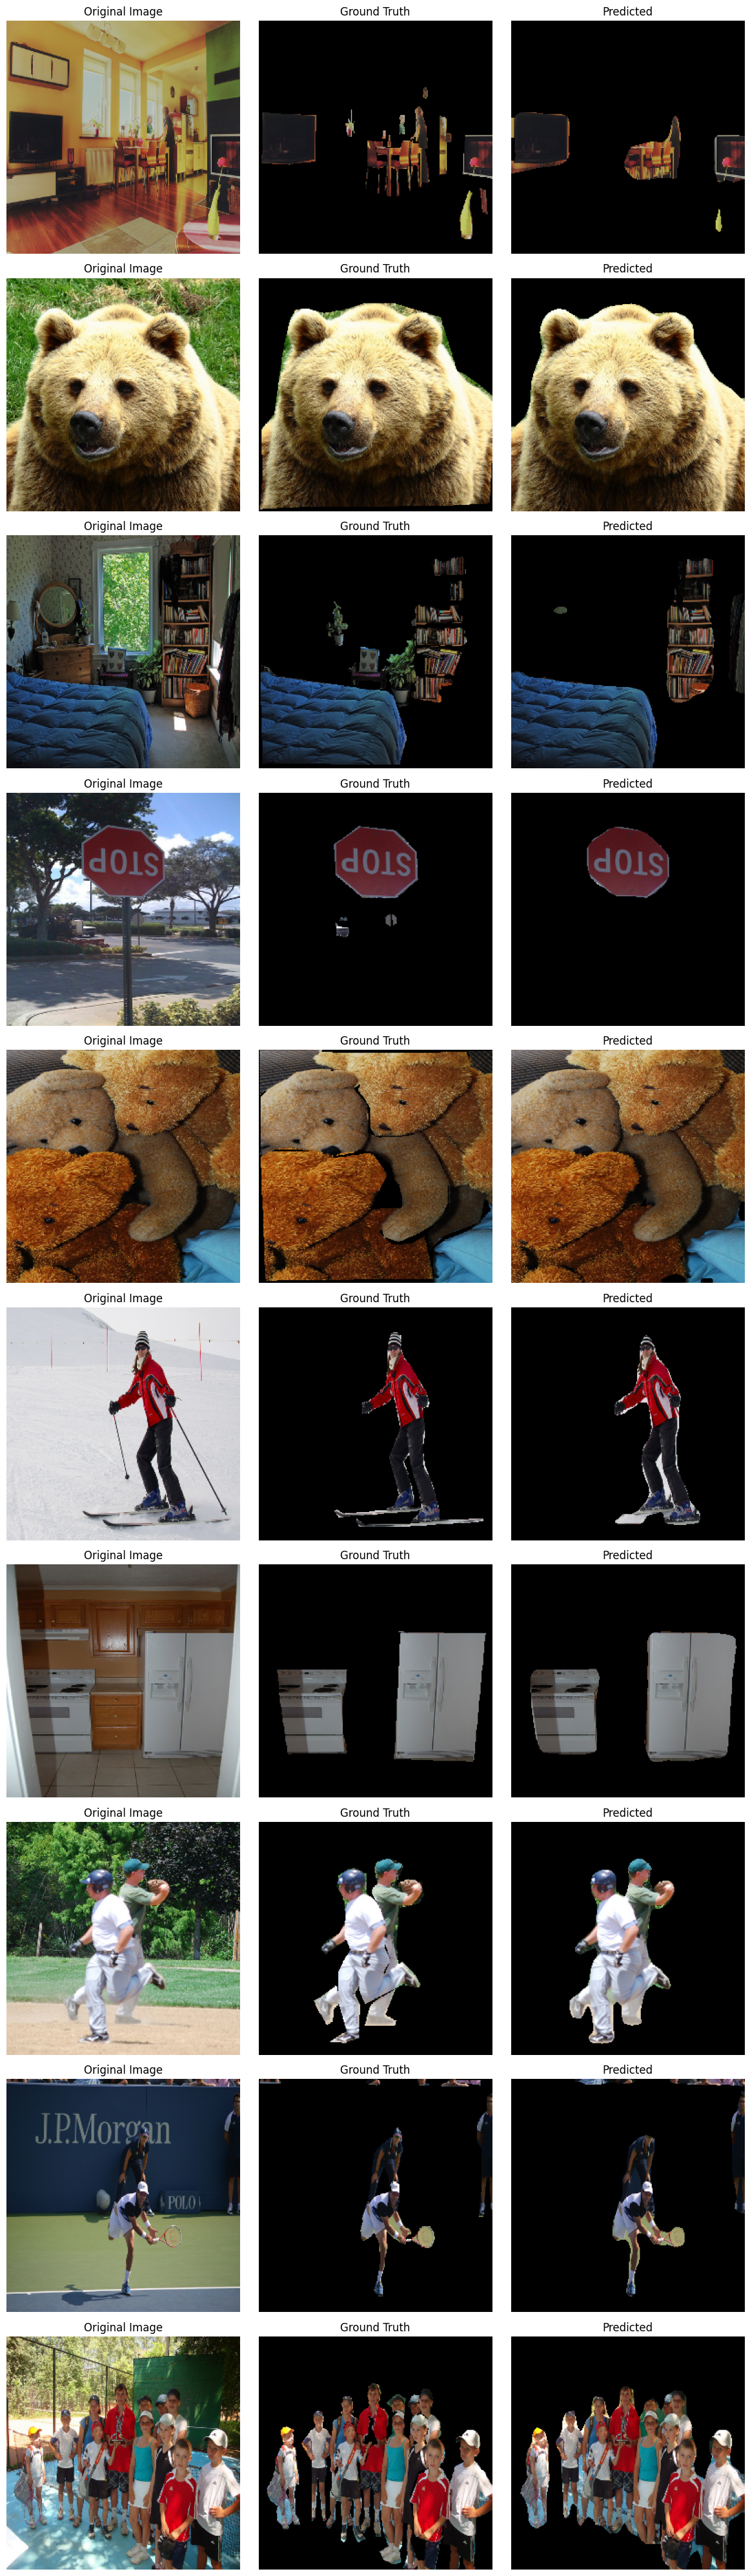

In [12]:
import torch
import numpy as np
import matplotlib.pyplot as plt

# Number of images you want to display
num_to_show = 10

# Collect images and masks from multiple batches if needed
images_list = []
masks_list = []

collected = 0
val_loader_iter = iter(val_loader)

while collected < num_to_show:
    try:
        imgs, msks = next(val_loader_iter)
    except StopIteration:
        break  # No more data in val_loader
    images_list.append(imgs)
    masks_list.append(msks)
    collected += imgs.size(0)

# Concatenate and move to device
images = torch.cat(images_list, dim=0).to(device)
masks = torch.cat(masks_list, dim=0).to(device)

# Run model
model.eval()
with torch.no_grad():
    outputs = model(images)['out']
preds = torch.argmax(outputs, dim=1)

# Only keep up to num_to_show images
num_samples = min(num_to_show, len(images))

# Denormalize function (adjust if your dataset uses different mean/std)
def denormalize(img_tensor, mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]):
    img = img_tensor.clone().cpu()
    for t, m, s in zip(img, mean, std):
        t.mul_(s).add_(m)
    return np.clip(img.permute(1,2,0).numpy(), 0, 1)

# Plotting
plt.figure(figsize=(12, 4 * num_samples))

for i in range(num_samples):
    pred_mask = (preds[i] == 1).cpu().numpy().astype(np.uint8)
    gt_mask   = (masks[i] == 1).cpu().numpy().astype(np.uint8)

    img_np = denormalize(images[i])
    img_masked_pred = img_np * pred_mask[:, :, None]
    img_masked_gt   = img_np * gt_mask[:, :, None]

    # Original Image
    plt.subplot(num_samples, 3, i*3+1)
    plt.imshow(img_np)
    plt.axis("off")
    plt.title("Original Image")
    plt.gca().set_facecolor('black')

    # Ground truth
    plt.subplot(num_samples, 3, i*3+2)
    plt.imshow(img_masked_gt)
    plt.axis("off")
    plt.title("Ground Truth")
    plt.gca().set_facecolor('black')

    # Prediction
    plt.subplot(num_samples, 3, i*3+3)
    plt.imshow(img_masked_pred)
    plt.axis("off")
    plt.title("Predicted")
    plt.gca().set_facecolor('black')

plt.tight_layout()
plt.show()
